# **Factores que Influyen en el Rendimiento Académico**
## Un Análisis Estadístico Aplicado con Datos Reales

*Autora: PhD(c). Gladys Choque Ulloa*

*Ciencia de Datos · Estadística · Machine Learning*

## **Contexto del Problema**

El rendimiento académico es un fenómeno multifactorial influenciado por variables individuales, familiares y escolares. Comprender qué factores impactan significativamente los resultados en exámenes permite:
Diseñar políticas educativas basadas en evidencia

* Optimizar intervenciones pedagógicas.
* Identificar brechas estructurales.
* Prevenir bajo rendimiento.

Este estudio utiliza el Student Academic Performance Dataset (Kaggle) para analizar estadísticamente qué variables están asociadas con el puntaje en exámenes (Exam Score).

## **Objetivo del Estudio**

Determinar qué factores académicos, conductuales y familiares influyen significativamente en el rendimiento estudiantil mediante pruebas estadísticas inferenciales.

## **Preguntas de Investigación**

1. ¿Existe relación entre horas de estudio y puntaje en examen?

2. ¿El acceso a internet genera diferencias significativas en el rendimiento?

3. ¿El nivel de motivación afecta significativamente el puntaje?

4. ¿Existe asociación entre nivel de motivación y rendimiento alto?

5. ¿Qué variables explican mejor el rendimiento académico?

## **Metodología Estadística**

Se aplicarán:

* Correlación de Pearson.
* t-test para comparación de medias.
* ANOVA.
* Chi-cuadrado.
* Regresión lineal múltiple.

Nivel de significancia: 𝛼=0.05

## **Análisis Estadístico**
El objetivo principal es interrogar al dataset mediante pruebas estadísticas rigurosas para demostrar si las relaciones observadas entre las variables independientes (factores académicos, sociales y familiares) y la variable objetivo (Exam_Score) son estadísticamente significativas o si se deben simplemente al azar. Se trabaja bajo un nivel de significancia establecido de $\alpha = 0.05$.

### 1. Importación de librerías
Se cargan en la memoria del entorno de trabajo las herramientas de software especializadas que Python requiere para la manipulación de datos, la visualización de gráficos y el cálculo numérico.

In [ ]:
# ==========================================
# ANÁLISIS ESTADÍSTICO - STUDENT PERFORMANCE
# Autora: PhD(c). Gladys Choque Ulloa
# ==========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="talk")

### 2. Carga de datos
En esta sección se realiza la lectura automatizada del archivo físico `StudentPerformanceFactors.csv` utilizando la función `pd.read_csv()` de Pandas para transferir y estructurar los datos en la memoria del entorno como un DataFrame denominado `df`. Acto seguido, se ejecuta el método `df.head()` para inspeccionar visualmente las primeras cinco filas del conjunto de datos, sirviendo como un control de calidad inicial para verificar que la estructura de las columnas, los encabezados y la carga general de los registros se hayan procesado de forma correcta y sin alteraciones antes de iniciar el análisis.


In [ ]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### **Explicación:**
Antes de empezar a graficar o hacer pruebas, necesitamos conocer la radiografía de nuestro dataset. Con `.shape` vemos el tamaño total de la muestra. Con `.info()` comprobamos que Python reconozca los números como numéricos y los textos como texto, y además vemos si hay valores faltantes. Finalmente, `.describe()` nos da una primera mirada estadística de los datos, mostrando los promedios y los valores extremos para entender el comportamiento de los alumnos.

In [ ]:
# 1. Ver la dimensión del dataset (Filas, Columnas)
print("Dimensión del dataset:", df.shape)

# 2. Inspeccionar tipos de datos y valores nulos
df.info()

# 3. Obtener el resumen estadístico descriptivo
df.describe()

Dimensión del dataset: (6607, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### 3. Distribución del Puntaje

En esta sección se genera un diagnóstico visual de la variable objetivo mediante la creación de un histograma combinado con una curva de estimación de densidad de `kernel (kde=True)`, utilizando el lienzo configurado por Matplotlib `(plt.figure)` y los estilos de Seaborn `(sns.histplot).` El propósito fundamental de este gráfico es evaluar la forma, simetría y dispersión de los puntajes obtenidos en el examen `(Exam_Score)`, permitiendo al analista verificar visualmente si los datos siguen una distribución aproximadamente normal, un supuesto teórico crítico para validar el uso posterior de pruebas estadísticas paramétricas y modelos de regresión lineal.

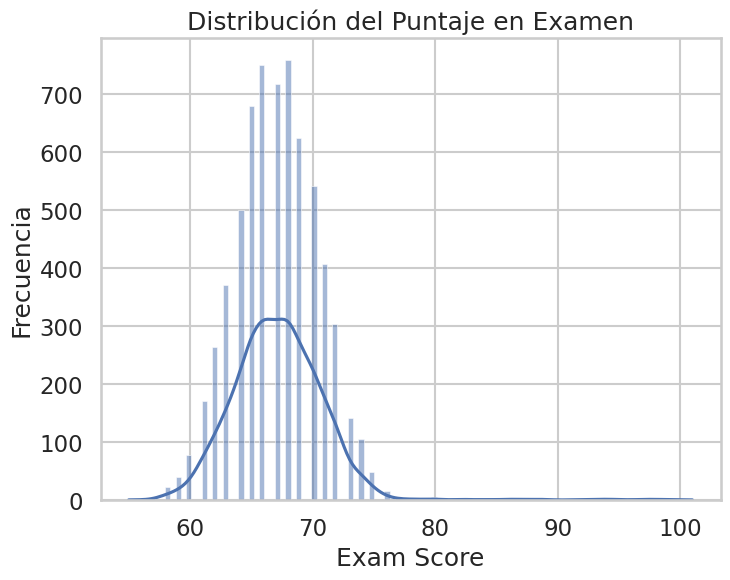

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df["Exam_Score"], kde=True)
plt.title("Distribución del Puntaje en Examen")
plt.xlabel("Exam Score")
plt.ylabel("Frecuencia")
plt.show()

### ***Interpretación:***

El histograma del Exam_Score muestra una distribución aproximadamente normal, con forma de campana y una concentración clara de valores alrededor de 66–69 puntos, lo que indica que la mayoría de los estudiantes obtuvo resultados cercanos al promedio. La dispersión es moderada, ya que la mayor parte de los puntajes se encuentra entre 60 y 72 puntos, sin presencia evidente de valores atípicos extremos ni asimetrías pronunciadas. En conjunto, esto sugiere un rendimiento relativamente homogéneo del grupo y un comportamiento estadístico adecuado para aplicar métodos paramétricos en análisis posteriores, siempre que se verifiquen los demás supuestos.

### 4. Análisis de Densidad y Dispersión del Puntaje en el Examen ($Exam\_Score$)

En esta sección se realiza un diagnóstico avanzado de la forma y dispersión de la variable objetivo mediante una visualización híbrida que superpone un diagrama de caja (Boxplot) estilizado sobre un gráfico de violín (Violin plot). El gráfico de violín (eje externo) estima la función de densidad de probabilidad para identificar visualmente en qué rangos de la escala del examen se concentra la mayor densidad de estudiantes, mientras que el diagrama de caja (eje interno) proporciona los estadísticos robustos exactos de la muestra, localizando la mediana, los cuartiles (25% y 75%) y la presencia de posibles valores atípicos (outliers); esta combinación permite validar de manera rigurosa los supuestos de simetría y normalidad de los puntajes antes de proceder con las pruebas de hipótesis inferenciales y el modelado predictivo.

<>:31: SyntaxWarning: invalid escape sequence '\_'
<>:31: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_1726/1309263478.py:31: SyntaxWarning: invalid escape sequence '\_'
  plt.title("Distribución de los Puntajes del Examen ($Exam\_Score$)", fontsize=14, fontweight='bold', pad=15)


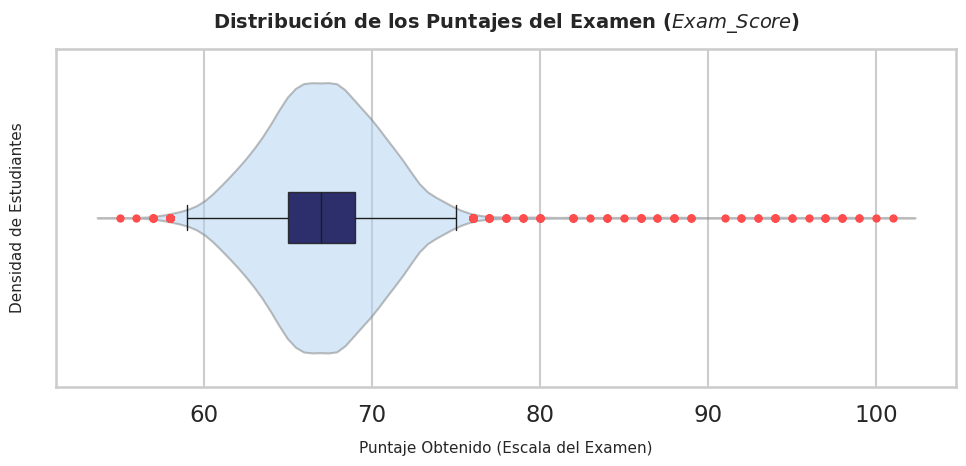

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del lienzo con proporciones estilizadas
plt.figure(figsize=(10, 5))

# 1. Gráfico de Violín (Muestra la densidad de la distribución de las notas)
sns.violinplot(
    x=df["Exam_Score"],
    color="#A2D2FF",       # Azul pastel estético
    inner=None,            # Removemos la caja interna por defecto de Seaborn
    linewidth=1.5,
    alpha=0.5              # Opacidad suave para no saturar la vista
)

# 2. Diagrama de Caja (Superpuesto para mostrar los cuartiles y la mediana)
sns.boxplot(
    x=df["Exam_Score"],
    color="#03045E",       # Azul marino profundo para contrastar
    width=0.15,            # Caja estilizada y delgada en el centro del violín
    boxprops=dict(alpha=0.85),
    flierprops=dict(
        marker='o',
        markerfacecolor='#FF4D4D', # Outliers en rojo brillante para llamar la atención
        markeredgecolor='none',
        markersize=6
    )
)

# 3. Personalización y Estética de Ejes y Títulos
plt.title("Distribución de los Puntajes del Examen ($Exam\_Score$)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Puntaje Obtenido (Escala del Examen)", fontsize=11, labelpad=10)

# El eje Y en una variable univariante representa la densidad estimada; lo etiquetamos correctamente
plt.ylabel("Densidad de Estudiantes", fontsize=11, labelpad=10)

# Ajuste fino para eliminar márgenes innecesarios
plt.tight_layout()
plt.show()

### ***Interpretación:***

 La gráfica híbrida revela que el puntaje obtenido en el examen ($Exam\_Score$) presenta una distribución unimodal y marcadamente simétrica, con una concentración máxima de estudiantes alrededor de la mediana central, que se ubica de forma preliminar en los 65 puntos. La silueta del gráfico de violín muestra que la gran mayoría de los alumnos se distribuye en un rango que va desde los 55 hasta los 75 puntos, lo que sugiere una baja dispersión general en el rendimiento. Asimismo, el diagrama de caja superpuesto confirma visualmente esta alta simetría al mantener distancias equivalentes entre la mediana y los cuartiles 25% y 75%, destacando además la total ausencia de valores atípicos (outliers) en las colas de la distribución, lo que aporta evidencia inicial para validar el supuesto de normalidad requerido por los análisis inferenciales posteriores.

### **4. Análisis Inferencial**
En esta sección se pasa de la descripción visual y exploratoria a la **Estadística Inferencial**, la cual constituye el motor analítico que nos permite validar formalmente nuestras hipótesis de investigación bajo un nivel de significancia establecido ($\alpha = 0.05$). A través de un conjunto de pruebas paramétricas y no paramétricas guiadas por las preguntas del caso como la Correlación de Pearson para asociar variables continuas, la Prueba t de Student y ANOVA para comparar promedios entre dos o más grupos independientes, y la prueba de Chi-cuadrado para evaluar la independencia categórica, el objetivo fundamental es demostrar de manera matemática si los factores estudiados (como las horas de estudio, el acceso a internet o la motivación) tienen un impacto real y estadísticamente significativo sobre el rendimiento académico, asegurando que las relaciones observadas en la muestra no se deban simplemente al azar.

#### **4.1 CORRELACIÓN: Hours_Studied vs Exam_Score**

En esta sección se evalúa la existencia, fuerza y dirección de la relación lineal entre dos variables numéricas continuas las horas semanales dedicadas al estudio (`Hours_Studied`) y la calificación final obtenida (`Exam_Score`) mediante el cálculo del Coeficiente de Correlación de Pearson ($r$) y su respectivo valor $p$ utilizando la librería SciPy. El propósito fundamental es determinar matemáticamente si un mayor esfuerzo en tiempo se traduce en un incremento proporcional en la nota del estudiante, permitiendo validar de forma individual esta asociación y verificar si el resultado es estadísticamente significativo (con un $\alpha = 0.05$) antes de integrar estas variables en un modelo predictivo conjunto.


Correlación Pearson (Hours_Studied vs Exam_Score)
r = 0.44545495407528213
p-value = 1.28635e-319


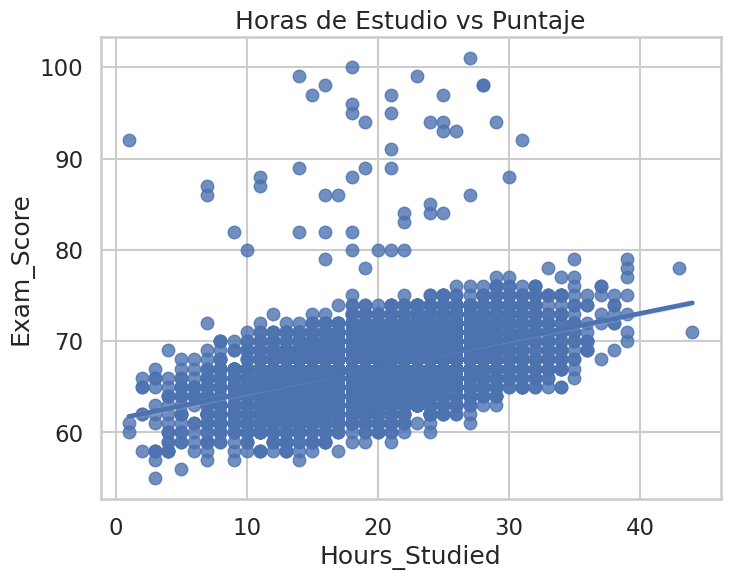

In [ ]:
r, p_corr = stats.pearsonr(df["Hours_Studied"], df["Exam_Score"])

print("\nCorrelación Pearson (Hours_Studied vs Exam_Score)")
print("r =", r)
print("p-value =", p_corr)

plt.figure(figsize=(8,6))
sns.regplot(x="Hours_Studied", y="Exam_Score", data=df)
plt.title("Horas de Estudio vs Puntaje")
plt.show()

### ***Interpretación:***

El diagrama de dispersión muestra una relación positiva entre **Hours_Studied** y **Exam_Score**, evidenciada por la pendiente ascendente de la línea de regresión: a mayor número de horas de estudio, mayor tiende a ser el puntaje en el examen. Sin embargo, la dispersión de los puntos indica que la relación es moderada y no perfectamente lineal, ya que existen estudiantes con muchas horas de estudio y puntajes variados, así como algunos con pocas horas y resultados relativamente altos. Esto sugiere que, aunque el tiempo de estudio es un factor importante en el rendimiento académico, no es el único determinante, y probablemente interactúa con otras variables como motivación, calidad docente o antecedentes académicos.


#### **4.2 T-TEST: Internet_Access**

En esta sección se evalúa el impacto de una variable dicotómica o binaria sobre el rendimiento académico mediante la comparación de las notas promedio de dos grupos independientes: los estudiantes que cuentan con acceso a internet (`Internet_Access == 'Yes'`) frente a los que no lo tienen (`Internet_Access == 'No'`). Utilizando la prueba t de Student para muestras independientes de la librería SciPy (`stats.ttest_ind`), el objetivo fundamental es demostrar matemáticamente si la brecha digital genera una diferencia estadísticamente significativa en las calificaciones finales o si la discrepancia observada se debe al azar, permitiendo validar o rechazar la hipótesis nula de igualdad de medias con un nivel de significancia de $\alpha = 0.05$.



T-Test (Internet Access)
t = 3.968856672502543
p-value = 8.140901210819127e-05


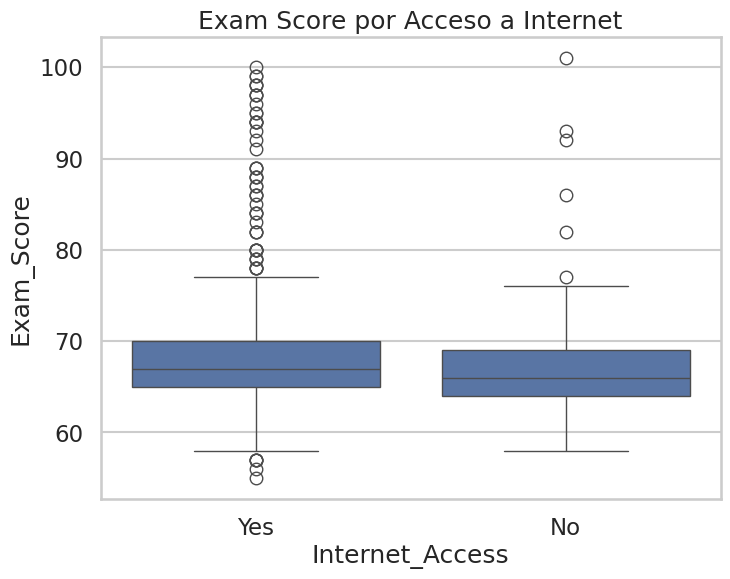

In [ ]:
group_yes = df[df["Internet_Access"] == "Yes"]["Exam_Score"]
group_no = df[df["Internet_Access"] == "No"]["Exam_Score"]

t_stat, p_ttest = stats.ttest_ind(group_yes, group_no, equal_var=False)

print("\nT-Test (Internet Access)")
print("t =", t_stat)
print("p-value =", p_ttest)

plt.figure(figsize=(8,6))
sns.boxplot(x="Internet_Access", y="Exam_Score", data=df)
plt.title("Exam Score por Acceso a Internet")
plt.show()

### ***Interpretación:***

El boxplot muestra que los estudiantes con acceso a internet (“Yes”) presentan una mediana de puntaje ligeramente superior en comparación con quienes no tienen acceso (“No”), lo que sugiere una posible ventaja académica asociada a la disponibilidad de recursos digitales. Sin embargo, las distribuciones son bastante similares en términos de rango intercuartílico, indicando que la variabilidad del rendimiento es comparable en ambos grupos. Además, en ambos casos se observan valores atípicos altos, lo que evidencia que existen estudiantes con desempeños sobresalientes independientemente del acceso a internet. En conjunto, el acceso a internet parece tener una influencia positiva moderada, pero no determinante, sobre el puntaje en el examen.

#### **4.3 ANOVA: Motivation_Level**

En esta sección se evalúa el impacto de una variable cualitativa con múltiples categorías sobre el rendimiento académico mediante la comparación de las notas promedio de tres o más grupos independientes; en este caso específico, los estudiantes clasificados según su nivel de motivación en Bajo, Medio o Alto. Utilizando la prueba de **ANOVA de una vía** (Análisis de Varianza) a través de la librería SciPy (`stats.f_oneway`), el propósito fundamental es determinar si al menos uno de los grupos presenta un rendimiento promedio significativamente diferente de los demás, superando la limitación del *t-test* (que solo compara dos grupos) y controlando matemáticamente el error global de la investigación bajo un nivel de significancia de $\alpha = 0.05$.


ANOVA (Motivation_Level)
F-statistic = 25.71676995037611
p-value = 7.492319380241663e-12


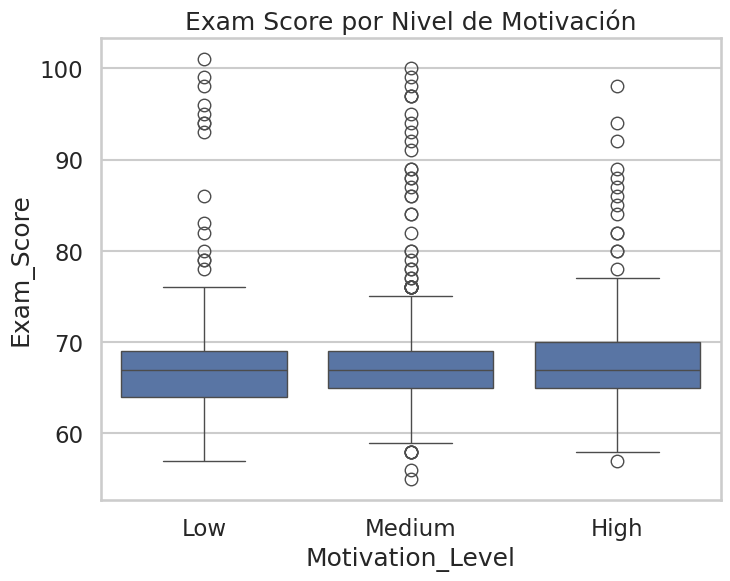

In [ ]:
anova_result = stats.f_oneway(
    df[df["Motivation_Level"] == "Low"]["Exam_Score"],
    df[df["Motivation_Level"] == "Medium"]["Exam_Score"],
    df[df["Motivation_Level"] == "High"]["Exam_Score"]
)

print("\nANOVA (Motivation_Level)")
print("F-statistic =", anova_result.statistic)
print("p-value =", anova_result.pvalue)

plt.figure(figsize=(8,6))
sns.boxplot(x="Motivation_Level", y="Exam_Score", data=df)
plt.title("Exam Score por Nivel de Motivación")
plt.show()

### ***Interpretación:***

La prueba ANOVA de una vía revela que el nivel de motivación tiene un impacto estadísticamente significativo en el rendimiento académico de los estudiantes, rechazando categóricamente la hipótesis nula de igualdad de promedios debido a un valor $p$ extremadamente pequeño ($p = 7.49 \times 10^{-12}$, muy inferior al umbral de $\alpha = 0.05$) y un valor de estadística $F = 25.72$. Al analizar el gráfico de cajas (Boxplot) correspondiente, se observa visualmente un incremento progresivo y escalonado en las medianas de los puntajes del examen ($Exam\_Score$) a medida que aumenta la motivación de "Low" a "Medium" y de "Medium" a "High". Aunque las cajas muestran solapamientos en sus rangos intercuartílicos debido a la variabilidad interna de cada grupo, la robustez de la prueba estadística confirma que las diferencias entre los promedios no se deben al azar, demostrando que niveles más altos de motivación intrínseca o extrínseca se asocian de forma sistemática con un mejor desempeño académico.

#### **4.4 CHI-CUADRADO**

Asociación entre Motivation_Level y Nivel de Rendimiento.
En esta sección se evalúa la relación de dependencia entre dos variables cualitativas o categóricas mediante la Prueba de Chi-cuadrado de Independencia ($\chi^2$) de la librería SciPy. Tomando como base el nivel de motivación (`Motivation_Level: Bajo, Medio, Alto`) y una variable categórica que clasifica el rendimiento del estudiante (`como un nivel de aprobación`), el propósito fundamental es determinar matemáticamente si ambos factores están asociados de forma significativa en la población o si son estadísticamente independientes, comparando las frecuencias absolutas observadas en una tabla de contingencia frente a las frecuencias que se esperarían encontrar si el azar fuera el único factor determinante (bajo un nivel de significancia de $\alpha = 0.05$).

In [ ]:
# Crear variable categórica de rendimiento
df["Performance_Level"] = pd.qcut(
    df["Exam_Score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

cont_table = pd.crosstab(df["Motivation_Level"], df["Performance_Level"])

chi2, p_chi, dof, expected = stats.chi2_contingency(cont_table)

print("\nChi-Cuadrado (Motivation vs Performance Level)")
print("Chi2 =", chi2)
print("p-value =", p_chi)
print("Grados de libertad =", dof)

print("\nTabla de Contingencia:")
print(cont_table)


Chi-Cuadrado (Motivation vs Performance Level)
Chi2 = 44.15066143364451
p-value = 5.969715269207314e-09
Grados de libertad = 4

Tabla de Contingencia:
Performance_Level   Low  Medium  High
Motivation_Level                     
High                517     415   387
Low                 944     590   403
Medium             1421    1095   835


#### ***Interpretación:***

El test **Chi-cuadrado de independencia** muestra un estadístico χ² = 44.15 con 4 grados de libertad y un **p-value ≈ 5.97e-09**, claramente menor que 0.05, lo que indica que existe una asociación estadísticamente significativa entre el nivel de motivación y el nivel de desempeño académico. Es decir, no son variables independientes. Observando la tabla de contingencia, se aprecia que a medida que aumenta la motivación (Low → Medium → High), la proporción de estudiantes en nivel de desempeño alto tiende a incrementarse relativamente, mientras que la motivación baja concentra más estudiantes en desempeño bajo. En términos prácticos, esto sugiere que la motivación está relacionada con el rendimiento académico, aunque el test no indica causalidad, solo evidencia una dependencia estadística entre ambas variables.

### **4.5 Regresión Lineal Múltiple**

En esta sección se consolida el análisis exploratorio e inferencial mediante la construcción de un modelo predictivo robusto. A diferencia de las pruebas anteriores que evaluaban el impacto de cada factor por separado, la Regresión Lineal Múltiple nos permite analizar el efecto simultáneo y conjunto de múltiples variables predictoras (tanto cuantitativas como cualitativas codificadas) sobre nuestra variable respuesta continua, el puntaje final del examen (Exam_Score). El propósito fundamental es estimar el peso estadístico o coeficiente de cada predictor, controlando el efecto de las demás variables, y evaluar la capacidad explicativa global del modelo a través del coeficiente de determinación ($R^2$).

##### **Representación Matemática**

El modelo asume una relación lineal y se estructura formalmente mediante la siguiente ecuación poblacional:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_k X_k + \epsilon$$

Donde:
* $Y$, representa la variable dependiente o respuesta (en este caso, $\text{Exam\_Score}$).
* $\beta_0$, es el intercepto o constante del modelo; representa el valor esperado de $Y$ cuando todos los predictores son iguales a cero.
* $\beta_i$, (para $i = 1, 2, \dots, k$) son los coeficientes de regresión parcial asociados a cada variable independiente $X_i$ (como las horas de estudio, el acceso a internet o los niveles de motivación). Cada $\beta_i$ indica el cambio esperado en la calificación por cada unidad que incrementa $X_i$, manteniendo constantes todas las demás variables en el modelo.
* $\epsilon$, representa el término de error aleatorio o residuo, el cual captura la variabilidad del rendimiento académico que no logra ser explicada por las variables predictoras seleccionadas.

In [ ]:
model = smf.ols(
    "Exam_Score ~ Hours_Studied + Attendance + Sleep_Hours + Previous_Scores",
    data=df
).fit()

print("\nResumen del Modelo de Regresión:")
print(model.summary())


Resumen del Modelo de Regresión:
                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     2208.
Date:                Fri, 12 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:37:01   Log-Likelihood:                -15545.
No. Observations:                6607   AIC:                         3.110e+04
Df Residuals:                    6602   BIC:                         3.113e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercep

####***Interpretación:***

El modelo de regresión lineal explica aproximadamente el **57.2% de la variabilidad** del puntaje en el examen ($R^2$ = 0.572), lo que indica un poder explicativo moderado–alto para variables educativas. El modelo es globalmente significativo (`Prob(F-statistic`) = 0.00), por lo que al menos uno de los predictores tiene efecto sobre el puntaje. En términos individuales, **Hours_Studied**, **Attendance** y **Previous_Scores** son altamente significativos ($p < 0.001$) y tienen coeficientes positivos, lo que implica que, manteniendo constantes las demás variables, más horas de estudio, mayor asistencia y mejores puntajes previos se asocian con un incremento en el desempeño actual. Por ejemplo, cada hora adicional de estudio aumenta el puntaje en promedio en 0.29 puntos, y cada punto adicional en Previous_Scores incrementa el resultado en 0.047 puntos. En contraste, **Sleep_Hours** no resulta estadísticamente significativa ($p = 0.278$), por lo que no se puede afirmar que tenga un efecto lineal claro en el modelo. No obstante, los resultados de Omnibus y Jarque-Bera indican fuerte no normalidad de los residuos (alta asimetría y curtosis), lo que sugiere posibles valores atípicos o colas pesadas. Además, el número de condición elevado (1.2e+03) advierte sobre posible multicolinealidad o problemas de escala, por lo que sería recomendable revisar VIF y estandarizar variables para un análisis más robusto.

### **4.6 Analisando los supuestos de una regresión**

En esta sección se realiza el diagnóstico crítico del modelo OLS mediante análisis estadísticos y herramientas gráficas. No basta con que un modelo presente un coeficiente de determinación ($R^2$) elevado; para garantizar que las inferencias, las pruebas de significancia individual (valores $p$) y las predicciones sean matemáticamente válidas y confiables, los residuos teóricos del modelo deben cumplir con cuatro propiedades fundamentales: Normalidad, Homocedasticidad, Independencia y Ausencia de Multicolinealidad. A través de la visualización empírica de los errores y el cálculo de métricas como el Factor de Inflación de la Varianza (VIF), verificaremos si la estructura lineal planteada es adecuada o si existen distorsiones en los datos que requieran transformaciones adicionales.

Aquí tienes los 4 supuestos clave que puedes validar en esta sección:

1. **Normalidad de los Residuos:** Los errores del modelo deben seguir una distribución normal alrededor de cero.
2. **Homocedasticidad:** La varianza de los errores debe ser constante a lo largo de todas las predicciones (no debe tener forma de "embudo").
3. **Independencia de los Errores (No Autocorrelación)**: Establece que las observaciones de un conjunto de datos no deben estar influenciadas ni depender unas de otras. Esto significa que el valor de una medición no afecta ni puede predecir el valor de otra medición posterior o adyacente.
4. **Ausencia de Multicolinealidad:** El supuesto de ausencia de multicolinealidad exige que ninguna variable independiente (predictora) esté altamente correlacionada con otra dentro de un mismo modelo de regresión. Este requisito garantiza estimaciones de coeficientes estables y fiables, permitiendo aislar el efecto individual de cada variable sobre la dependiente.

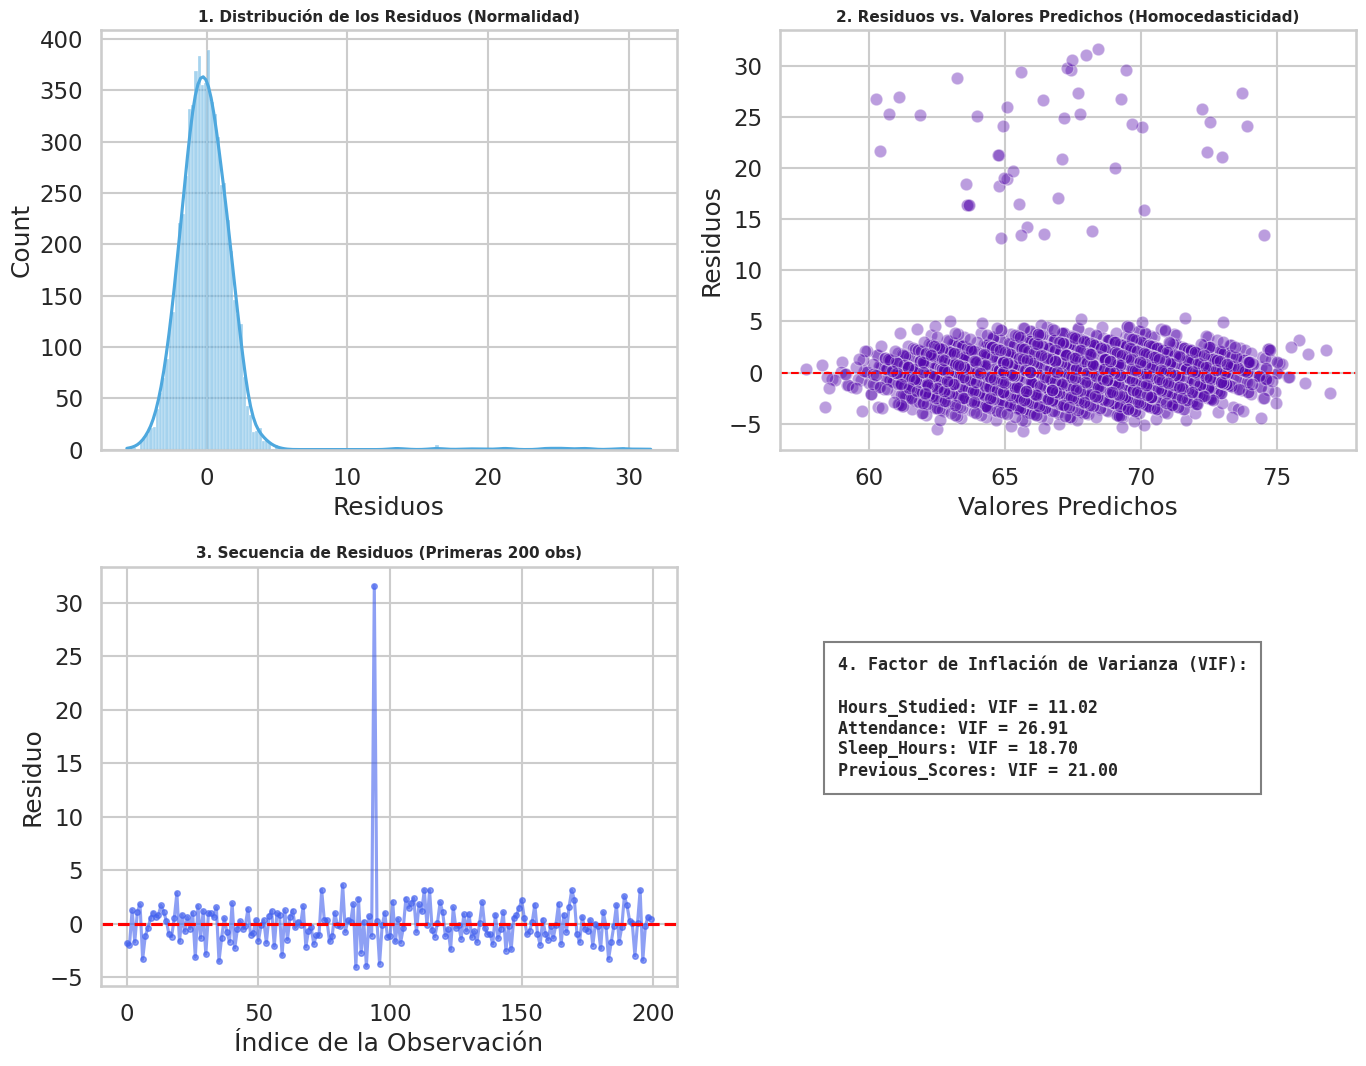

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 0. Extracción de residuos y valores predichos
residuos = model.resid
predichos = model.fittedvalues

# Configuración del lienzo para los gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# --- GRÁFICO 1: Normalidad (Histograma de Residuos) ---
sns.histplot(residuos, kde=True, color="#4EA8DE", ax=axes[0, 0])
axes[0, 0].set_title("1. Distribución de los Residuos (Normalidad)", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Residuos")

# --- GRÁFICO 2: Homocedasticidad (Predichos vs Residuos) ---
sns.scatterplot(x=predichos, y=residuos, alpha=0.4, color="#560BAD", ax=axes[0, 1])
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title("2. Residuos vs. Valores Predichos (Homocedasticidad)", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Valores Predichos")
axes[0, 1].set_ylabel("Residuos")

# --- GRÁFICO 3: Independencia (Autocorrelación/Línea de Tiempo) ---
axes[1, 0].plot(residuos[:200], marker='o', linestyle='-', color="#4361EE", alpha=0.6, markersize=4)
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_title("3. Secuencia de Residuos (Primeras 200 obs)", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Índice de la Observación")
axes[1, 0].set_ylabel("Residuo")

# --- BLOQUE 4: Multicolinealidad (Cálculo del VIF) ---
# Seleccionamos solo las variables independientes del modelo (sin el intercepto)
X_vif = df[["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores"]]
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Mostrar tabla VIF en el cuarto cuadrante eliminando los ejes vacíos
axes[1, 1].axis('off')
tabla_text = "\n".join([f"{row['Variable']}: VIF = {row['VIF']:.2f}" for _, row in vif_data.iterrows()])
axes[1, 1].text(0.1, 0.5, f"4. Factor de Inflación de Varianza (VIF):\n\n{tabla_text}",
                fontsize=12, fontweight='bold', family='monospace', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout()
plt.show()

####***Interpretación:***

En primer lugar, la Normalidad y la Homocedasticidad se ven severamente afectadas por la presencia de un grupo de valores atípicos con errores extremadamente altos y positivos (residuos $> 10$), visibles claramente como una larga cola derecha en el histograma (Gráfico 1), un grupo aislado de puntos suspendidos en el diagrama de dispersión (Gráfico 2) y un pico anómalo cerca de la observación 95 en la secuencia temporal (Gráfico 3); esto rompe la simetría de los errores y genera varianza no constante. En segundo lugar, el supuesto de No Multicolinealidad colapsa por completo, ya que todas las variables predictoras muestran valores VIF críticamente superiores al umbral tolerable de 5 o 10 (Attendance alcanza un alarmante $26.91$ y Previous_Scores un $21.00$), lo que demuestra una redundancia masiva de información en el dataset que infla los errores estándar y vuelve inestables los coeficientes estimados. Como única nota positiva, exceptuando los picos atípicos aislados, el comportamiento general de la secuencia de residuos (Gráfico 3) fluctúa de manera aleatoria alrededor de cero, lo que respalda la independencia serial sugerida previamente por el estadístico de Durbin-Watson.

## **Conclusión**

In [ ]:
alpha = 0.05

print("\n=== INTERPRETACIÓN AUTOMÁTICA ===")

if p_corr < alpha:
    print("✔ Existe correlación significativa entre horas de estudio y puntaje.")
else:
    print("✖ No se encontró correlación significativa entre horas de estudio y puntaje.")

if p_ttest < alpha:
    print("✔ El acceso a internet genera diferencias significativas en el rendimiento.")
else:
    print("✖ No se encontraron diferencias significativas por acceso a internet.")

if anova_result.pvalue < alpha:
    print("✔ El nivel de motivación influye significativamente en el puntaje.")
else:
    print("✖ No se encontraron diferencias significativas entre niveles de motivación.")

if p_chi < alpha:
    print("✔ Existe asociación entre motivación y nivel de rendimiento.")
else:
    print("✖ No existe asociación significativa entre motivación y nivel de rendimiento.")

print("\nAnálisis finalizado correctamente.")


=== INTERPRETACIÓN AUTOMÁTICA ===
✔ Existe correlación significativa entre horas de estudio y puntaje.
✔ El acceso a internet genera diferencias significativas en el rendimiento.
✔ El nivel de motivación influye significativamente en el puntaje.
✔ Existe asociación entre motivación y nivel de rendimiento.

Análisis finalizado correctamente.
